In [8]:
# Task 1: Fit a Univariate (single-variable) Gaussian to electricity-consumption data
# Why this section exists:
# - We want a simple probabilistic model of one variable: daily electricity consumption.
# - A Gaussian is useful because it summarizes the data using only mean and variance.

# Library imports
import numpy as np                 # Fast numerical arrays and statistics (mean/variance)
import matplotlib.pyplot as plt    # Plotting histogram and fitted curve
from scipy.stats import norm       # Gaussian PDF implementation for theoretical density curve

# Observed data (kWh) for 20 houses across one day each.
# This is the raw sample from which we estimate Gaussian parameters.
data = np.array([
    4.1, 4.3, 4.8, 5.0, 5.2,
    5.5, 6.0, 6.2, 4.9, 5.1,
    5.3, 5.8, 6.1, 4.7, 5.4,
    5.6, 4.6, 6.3, 5.9, 5.0
])


In [9]:
# Step 1: Estimate Gaussian parameters from data
# Mean (mu): center of the distribution (average consumption)
mean = np.mean(data)

# Variance (sigma^2): spread around the mean.
# np.var uses population variance by default (ddof=0).
# If you need sample variance, use np.var(data, ddof=1).
variance = np.var(data)

print(f"Mean: {mean}")
print(f"Variance: {variance}")


Mean: 5.29
Variance: 0.3809000000000001


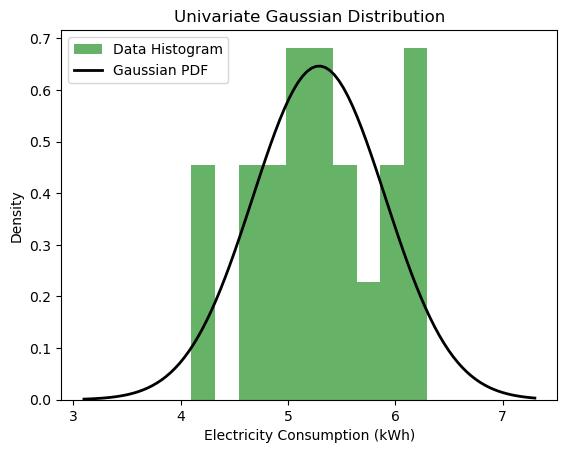

In [10]:
# Step 2: Build and visualize the fitted univariate Gaussian

# Create x-values for plotting the smooth theoretical curve.
# We extend beyond data min/max by 1 unit to show both tails clearly.
x = np.linspace(min(data) - 1, max(data) + 1, 100)

# Evaluate Gaussian density at each x using estimated mean and standard deviation.
# std = sqrt(variance), because variance = std^2.
pdf = norm.pdf(x, mean, np.sqrt(variance))

# Plot normalized histogram of observed data.
# density=True converts counts to a density scale so it can be compared with PDF.
plt.hist(data, bins=10, density=True, alpha=0.6, color='g', label='Data Histogram')

# Overlay fitted Gaussian curve.
plt.plot(x, pdf, 'k', linewidth=2, label='Gaussian PDF')

# Labels/legend make interpretation explicit.
plt.title('Univariate Gaussian Distribution')
plt.xlabel('Electricity Consumption (kWh)')
plt.ylabel('Density')
plt.legend()
plt.show()


# Key Formulas and Intuition

---

## 1) Univariate Gaussian (Normal Distribution)

For a single variable \( x \):

\[
p(x) = \frac{1}{\sqrt{2\pi\sigma^2}} 
\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
\]

### Intuition

- \( \mu \) → Mean (center of the distribution)
- \( \sigma^2 \) → Variance (controls spread)
- Larger variance → Wider bell curve  
- Smaller variance → Sharper peak  

This describes the probability density of a single continuous variable.

---

## 2) Covariance Matrix (2D Case)

For two features \( X_1 \) and \( X_2 \):

\[
\Sigma =
\begin{bmatrix}
\mathrm{Var}(X_1) & \mathrm{Cov}(X_1, X_2) \\
\mathrm{Cov}(X_2, X_1) & \mathrm{Var}(X_2)
\end{bmatrix}
\]

### Interpretation

- Diagonal elements → Variances  
  - \( \mathrm{Var}(X_1) \)
  - \( \mathrm{Var}(X_2) \)

- Off-diagonal elements → Covariances  
  - Measure how features move together  
  - Positive → Move in same direction  
  - Negative → Move in opposite directions  
  - Zero → No linear relationship  

---

## 3) Why Equal-Density Contours Form Ellipses

In a multivariate Gaussian distribution:

\[
(x-\mu)^T \Sigma^{-1} (x-\mu) = c
\]

This represents a quadratic form.

### Geometric Meaning

- If covariance ≈ 0 → Ellipses align with coordinate axes  
- If covariance > 0 → Ellipses tilt upward  
- If covariance < 0 → Ellipses tilt downward  

The covariance matrix controls:
- Orientation
- Stretch
- Shape of the distribution

---

## Key Insight

The covariance matrix determines the geometry of the probability distribution in higher dimensions.


Mean Vector: [4.94807674 2.00669138]
Covariance Matrix:[[ 0.20619247 -0.01772313]
 [-0.01772313  0.0818536 ]]


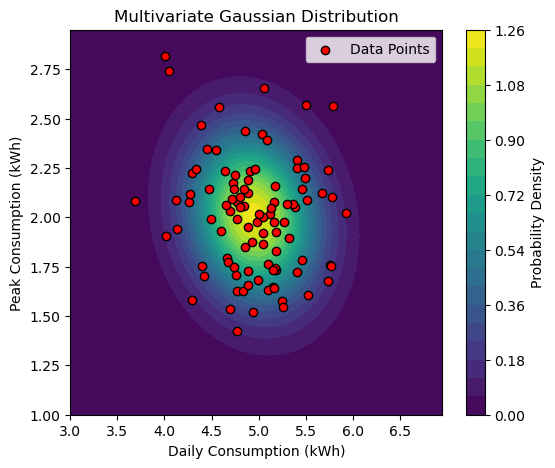

In [13]:
# Task 2: Understand covariance and elliptical contours in a Multivariate Gaussian
# Why this section exists:
# - Univariate Gaussian models one feature.
# - Multivariate Gaussian models multiple features together and captures relationships.
# - Covariance controls orientation/shape of contour ellipses.

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Seed for reproducibility: same random data every run.
np.random.seed(42)

# Generate synthetic data for two features:
# 1) daily consumption, 2) peak consumption
# These are sampled independently here; covariance from data should be near zero.
daily = np.random.normal(5, 0.5, 100)  # Mean=5, std=0.5
peak = np.random.normal(2, 0.3, 100)   # Mean=2, std=0.3

# Combine into a 2D dataset of shape (n_samples, 2).
X = np.column_stack((daily, peak))

# Estimate multivariate parameters from data.
# mean_vector = [mean_daily, mean_peak]
mean_vector = np.mean(X, axis=0)

# Covariance matrix contains variances on diagonal and covariance off-diagonal.
# It defines spread and tilt of Gaussian contours.
cov_matrix = np.cov(X.T)

print(f"Mean Vector: {mean_vector}")
print(f"Covariance Matrix:{cov_matrix}")

# Create multivariate Gaussian model with estimated parameters.
rv = multivariate_normal(mean_vector, cov_matrix)

# Build a 2D grid covering plausible value ranges for both variables.
x, y = np.mgrid[3:7:0.05, 1:3:0.05]
pos = np.dstack((x, y))

# Plot filled contour of probability density over the grid.
plt.figure(figsize=(6, 5))
plt.contourf(x, y, rv.pdf(pos), levels=20, cmap='viridis')
plt.colorbar(label='Probability Density')

# Overlay sampled points to compare observed data vs density regions.
plt.scatter(X[:, 0], X[:, 1], c='red', edgecolor='k', label='Data Points')
plt.title('Multivariate Gaussian Distribution')
plt.xlabel('Daily Consumption (kWh)')
plt.ylabel('Peak Consumption (kWh)')
plt.legend()
plt.show()
